# Customer Churn Prediction with XGBoost

0. Installation (if needed)

In [2]:
# Install required libraries (run only if not installed)
!pip install xgboost shap scikit-learn pandas matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


1. Generate Synthetic but Realistic Business Data

In [3]:
import numpy as np
import pandas as pd

# Set random seed for reproducibility
np.random.seed(42)

# Number of customers
n = 3000

# Create a synthetic dataset that mimics a SaaS business
df = pd.DataFrame({
    "tenure_months": np.random.randint(1, 60, n),           # Customer lifetime
    "monthly_fee": np.random.normal(60, 20, n).clip(20, 150),
    "usage_sessions": np.random.poisson(20, n),              # Monthly usage
    "avg_session_time": np.random.normal(30, 10, n).clip(5, 90),
    "num_support_tickets": np.random.poisson(2, n),
    "payment_delay_days": np.random.poisson(3, n),
    "plan_type": np.random.choice(
        ["Basic", "Pro", "Enterprise"], n, p=[0.5, 0.35, 0.15]
    ),
    "contract_type": np.random.choice(
        ["Monthly", "Annual"], n, p=[0.65, 0.35]
    )
})

# Define a non-linear churn probability (real-world behavior)
churn_prob = (
    0.3 * (df["tenure_months"] < 12) +
    0.4 * (df["usage_sessions"] < 10) +
    0.5 * (df["num_support_tickets"] > 3) +
    0.6 * (df["payment_delay_days"] > 5) +
    0.4 * (df["contract_type"] == "Monthly").astype(int)
)

# Generate churn label
df["churn"] = np.random.binomial(1, churn_prob.clip(0, 1))

df.head()

,tenure_months,monthly_fee,usage_sessions,avg_session_time,num_support_tickets,payment_delay_days,plan_type,contract_type,churn
0,39,59.599622,12,21.255198,1,2,Pro,Monthly,0
1,52,67.672239,16,15.954024,1,6,Basic,Annual,1
2,29,41.736022,26,23.866530,3,6,Basic,Monthly,1
3,15,54.356388,23,31.715903,1,1,Basic,Monthly,0
4,43,77.306338,24,39.283317,3,2,Enterprise,Monthly,1


2. Train-Test Split and Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [5]:
# Separate features and target
X = df.drop("churn", axis=1)
y = df["churn"]

# Numerical and categorical features
num_features = [
    "tenure_months",
    "monthly_fee",
    "usage_sessions",
    "avg_session_time",
    "num_support_tickets",
    "payment_delay_days"
]

cat_features = ["plan_type", "contract_type"]

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

# Train-test split with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

3. Model Training with XGBoost

In [6]:
from xgboost import XGBClassifier

# XGBoost model configuration (business-oriented defaults)
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="auc",
    random_state=42
)

In [7]:
# Full pipeline: preprocessing + model
pipe = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", xgb_model)
])

# Train the model
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocess',
                 ColumnTransformer(transformers=[('num', 'passthrough',
                                                  ['tenure_months',
                                                   'monthly_fee',
                                                   'usage_sessions',
                                                   'avg_session_time',
                                                   'num_support_tickets',
                                                   'payment_delay_days']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['plan_type',
                                                   'contract_type'])])),
                ('model',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsampl...
                               feature_types=None, gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=5, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, random_state=42, ...))])

4. Model Evaluation (Business-Oriented Metrics)

In [8]:
from sklearn.metrics import roc_auc_score, classification_report

# Predict churn probabilities
y_pred_proba = pipe.predict_proba(X_test)[:, 1]

# Binary predictions using default threshold
y_pred = (y_pred_proba > 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_test, y_pred_proba))
print(classification_report(y_test, y_pred))

ROC AUC: 0.8003156795058138
              precision    recall  f1-score   support

           0       0.71      0.78      0.74       344
           1       0.66      0.58      0.62       256

    accuracy                           0.69       600
   macro avg       0.68      0.68      0.68       600
weighted avg       0.69      0.69      0.69       600



⚠️ Business note:
In churn prediction, recall for churned customers (class 1) is usually more important than accuracy.

5. Model Explainability with SHAP

In [9]:
import shap

# Transform training data using the preprocessing step
X_train_transformed = pipe.named_steps["preprocess"].transform(X_train)

# Initialize SHAP explainer for tree-based models
explainer = shap.TreeExplainer(pipe.named_steps["model"])

# Compute SHAP values
shap_values = explainer.shap_values(X_train_transformed)

Global Feature Importance

/var/folders/x8/q2xc54s1541_9f8500fsv2980000gn/T/ipykernel_21334/395792484.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_train_transformed)


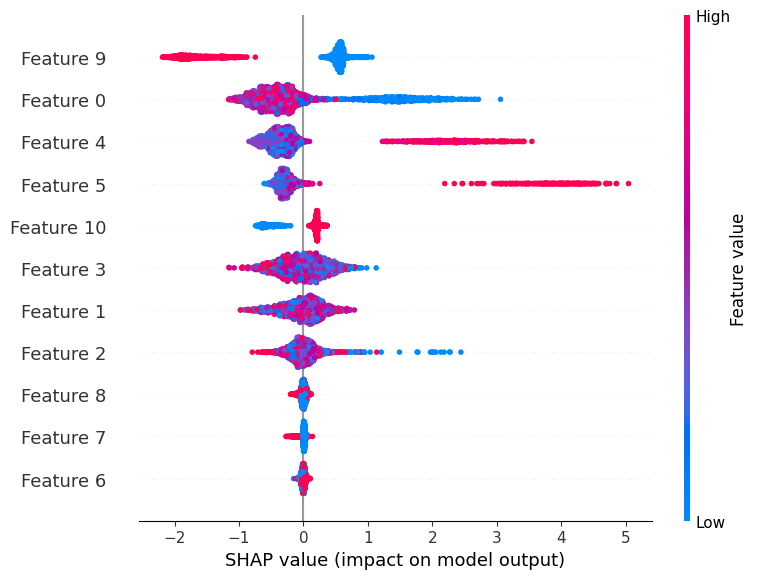

In [10]:
# Summary plot to understand overall feature impact
shap.summary_plot(shap_values, X_train_transformed)

Individual Prediction Explanation

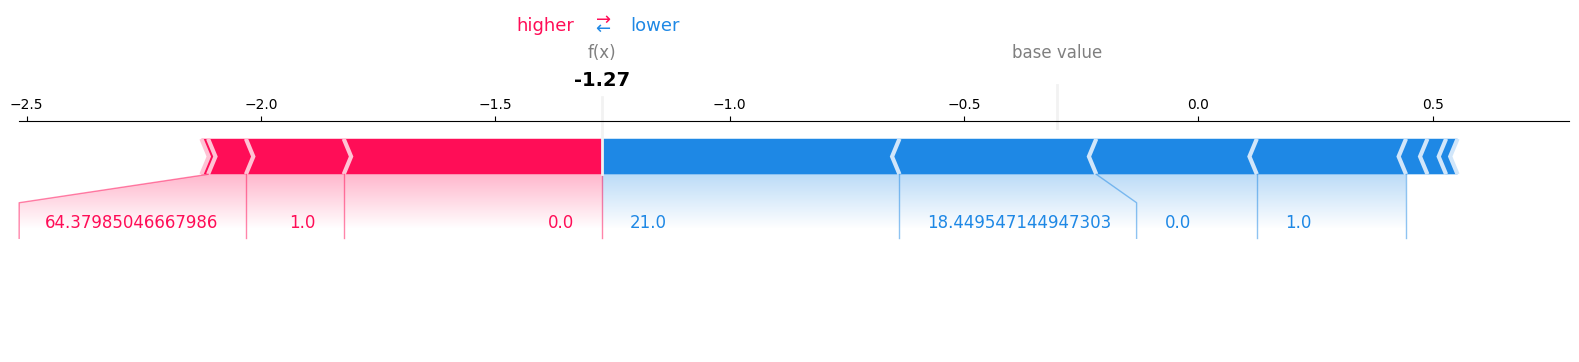

In [11]:
# Explain a single customer prediction
i = 10  # Example customer index

shap.force_plot(
    explainer.expected_value,
    shap_values[i],
    X_train_transformed[i],
    matplotlib=True
)

6. Identifying High-Risk Customers (Business Output)

In [13]:
# Create a results table for business stakeholders
results = X_test.copy()
results["churn_probability"] = y_pred_proba

# Identify high-risk customers
high_risk_customers = results[results["churn_probability"] > 0.7]

high_risk_customers.head()

,tenure_months,monthly_fee,usage_sessions,avg_session_time,num_support_tickets,payment_delay_days,plan_type,contract_type,churn_probability
36,59,71.562342,13,27.844245,4,5,Basic,Monthly,0.898892
1702,11,45.172134,14,37.847012,3,6,Enterprise,Monthly,0.992902
191,7,41.197022,20,36.805742,1,0,Basic,Monthly,0.858331
888,37,68.767652,23,21.339112,2,6,Basic,Monthly,0.989831
2408,42,49.783743,25,29.086687,4,3,Basic,Monthly,0.921266


# Threshold Optimization Based on Business Cost

1. Why Accuracy is not enough in Churn Prediction

In churn prediction problems, the default classification threshold (0.5) is usually not optimal from a business perspective.

This is because different types of errors have very different economic impacts.

##### False Negative (FN):
- The model predicts that the customer will NOT churn
- The customer actually churns
- Business impact: loss of recurring revenue

##### False Positive (FP):
- The model predicts that the customer WILL churn
- The customer actually stays
- Business impact: unnecessary retention cost (discounts, calls, campaigns)

In most businesses:
##### Cost(False Negative) >> Cost(False Positive)

##### Therefore, the optimal threshold should minimize TOTAL BUSINESS COST, not maximize accuracy.

2. Defining business costs for classification errors

In [14]:
# Define business costs (example values)
# These values should ideally be provided by the business team

COST_FALSE_NEGATIVE = 1000  # Revenue lost when a churned customer is not detected
COST_FALSE_POSITIVE = 50    # Cost of an unnecessary retention action

3. Evaluating business cost across different thresholds

In [15]:
import numpy as np
from sklearn.metrics import confusion_matrix

# Generate a range of possible decision thresholds
thresholds = np.linspace(0.01, 0.99, 99)

total_costs = []

for threshold in thresholds:
    # Convert predicted probabilities into binary predictions
    y_pred_threshold = (y_pred_proba >= threshold).astype(int)
    
    # Confusion matrix format:
    # [[TN, FP],
    #  [FN, TP]]
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()
    
    # Calculate total business cost for the current threshold
    total_cost = (
        fn * COST_FALSE_NEGATIVE +
        fp * COST_FALSE_POSITIVE
    )
    
    total_costs.append(total_cost)

4. Selecting the optimal threshold based on minimum cost

In [16]:
# Identify the threshold that minimizes total business cost
optimal_index = np.argmin(total_costs)
optimal_threshold = thresholds[optimal_index]

optimal_threshold

np.float64(0.08)

5. Visualizing the cost–threshold trade-off

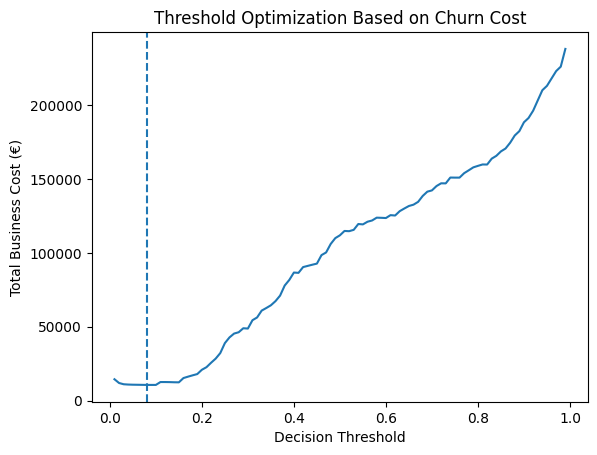

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(thresholds, total_costs)
plt.axvline(optimal_threshold, linestyle="--")
plt.xlabel("Decision Threshold")
plt.ylabel("Total Business Cost (€)")
plt.title("Threshold Optimization Based on Churn Cost")
plt.show()

##### Interpretation:
- Lower thresholds increase recall but generate more false positives
- Higher thresholds reduce false positives but increase false negatives
- The optimal threshold balances both effects based on their business costs


6. Comparing default vs cost-optimized thresholds

In [18]:
def compute_business_cost(y_true, y_pred, cost_fn, cost_fp):
    """
    Compute total business cost based on classification errors.
    
    Parameters:
    - y_true: Ground truth labels
    - y_pred: Model predictions
    - cost_fn: Cost of False Negatives
    - cost_fp: Cost of False Positives
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return fn * cost_fn + fp * cost_fp

In [19]:
# Cost using the default threshold (0.5)
cost_default_threshold = compute_business_cost(
    y_test,
    (y_pred_proba >= 0.5).astype(int),
    COST_FALSE_NEGATIVE,
    COST_FALSE_POSITIVE
)

# Cost using the optimized threshold
cost_optimized_threshold = compute_business_cost(
    y_test,
    (y_pred_proba >= optimal_threshold).astype(int),
    COST_FALSE_NEGATIVE,
    COST_FALSE_POSITIVE
)

cost_default_threshold, cost_optimized_threshold

(np.int64(111850), np.int64(10600))

7. Business interpretation and takeaways

In [20]:
cost_reduction_pct = (
    (cost_default_threshold - cost_optimized_threshold)
    / cost_default_threshold
) * 100

cost_reduction_pct

np.float64(90.52302190433616)

##### Cost-based threshold optimization reduced expected churn cost by ~90%.

Business takeaway:

By optimizing the classification threshold based on economic cost,
we move from a purely technical decision (threshold = 0.5) to a business-driven decision.

This approach directly answers questions such as:
- How much money are we expected to save?
- How aggressive should our retention strategy be?
- Where is the optimal balance between risk and cost?

This makes the model easier to justify to non-technical stakeholders and increases its real-world impact.